In [4]:
# Step 1: Load & Explore the Data


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("train.csv")  # replace with your actual file name
print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [6]:
df.info

<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520      

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
#Data Cleaning


# Fix the 11 missing Postal Codes:
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

In [12]:
# Fix date columns (convert to proper datetime)

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [13]:
#Add useful columns to analysis

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

In [14]:
#comfir everything

print("Shape:", df.shape)
print("Nulls left:", df.isnull().sum().sum())
df.head(3)

Shape: (9800, 22)
Nulls left: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Days to Ship
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,11,November,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017,11,November,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2017,6,June,4


In [15]:
#Pivot Table Analysis

#Revenue by region

region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales.columns = ['Region', 'Total Sales']
region_sales = region_sales.sort_values('Total Sales', ascending=False)
print(region_sales)

    Region  Total Sales
3     West  710219.6845
1     East  669518.7260
0  Central  492646.9132
2    South  389151.4590


In [16]:
#revenue by category
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales.columns = ['Category', 'Total Sales']
category_sales = category_sales.sort_values('Total Sales', ascending=False)
print(category_sales)

          Category  Total Sales
2       Technology  827455.8730
0        Furniture  728658.5757
1  Office Supplies  705422.3340


In [17]:
#revenue both region & category

pivot = pd.pivot_table(df, values='Sales', 
                       index='Region', 
                       columns='Category', 
                       aggfunc='sum').round(2)
print(pivot)

Category  Furniture  Office Supplies  Technology
Region                                          
Central   160317.46        163590.24   168739.21
East      206461.39        199940.81   263116.53
South     116531.48        124424.77   148195.21
West      245348.25        217466.51   247404.93


In [18]:
#revenue by year + month

monthly_sales = df.groupby(['Year', 'Month', 'Month Name'])['Sales'].sum().reset_index()
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])
print(monthly_sales.head(10))

   Year  Month Month Name       Sales
0  2015      1    January  14205.7070
1  2015      2   February   4519.8920
2  2015      3      March  55205.7970
3  2015      4      April  27906.8550
4  2015      5        May  23644.3030
5  2015      6       June  34322.9356
6  2015      7       July  33781.5430
7  2015      8     August  27117.5365
8  2015      9  September  81623.5268
9  2015     10    October  31453.3930


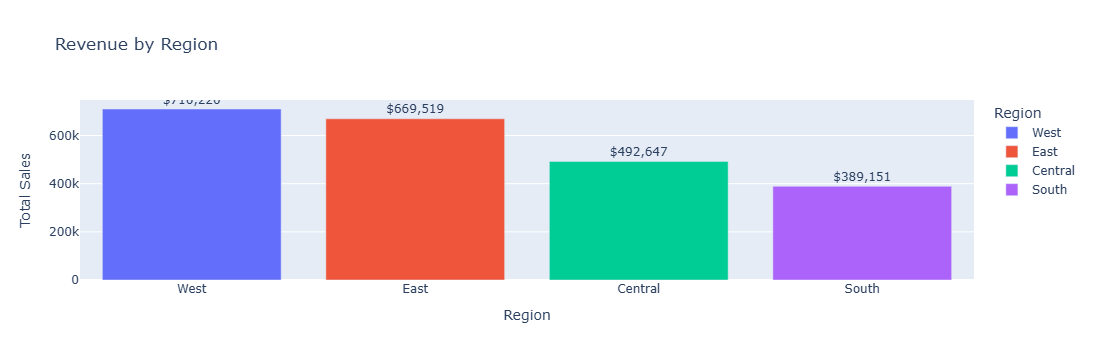

In [20]:
#Step 4: Interactive Dashboard with Plotly


#revenue by region (bar chart)
fig1 = px.bar(region_sales, x='Region', y='Total Sales',
              title='Revenue by Region',
              color='Region',
              text='Total Sales')
fig1.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig1.show()

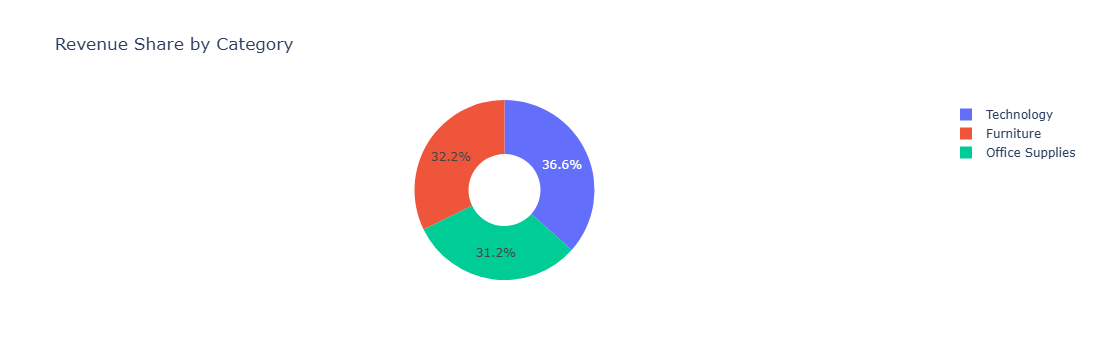

In [22]:
# revenue by category (pie chart)
fig2 = px.pie(category_sales, names='Category', values='Total Sales',
              title='Revenue Share by Category',
              hole=0.4)
fig2.show()


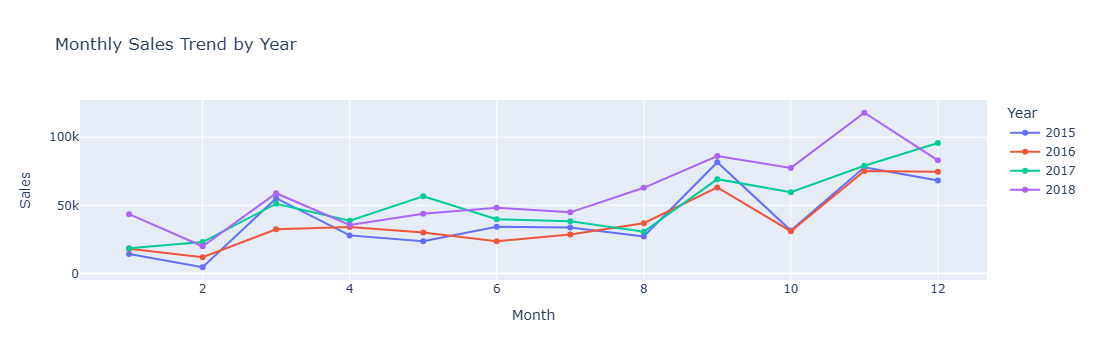

In [23]:
#monthly sale trending (line chart)
fig3 = px.line(monthly_sales, x='Month', y='Sales',
               color='Year',
               title='Monthly Sales Trend by Year',
               markers=True)
fig3.show()

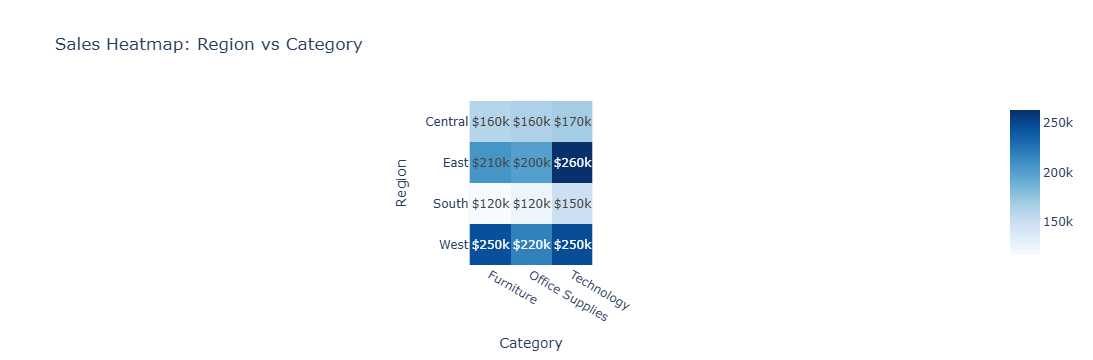

In [24]:
#region vs category heatmap
fig4 = px.imshow(pivot,
                 title='Sales Heatmap: Region vs Category',
                 text_auto='$.2s',
                 color_continuous_scale='Blues')
fig4.show()

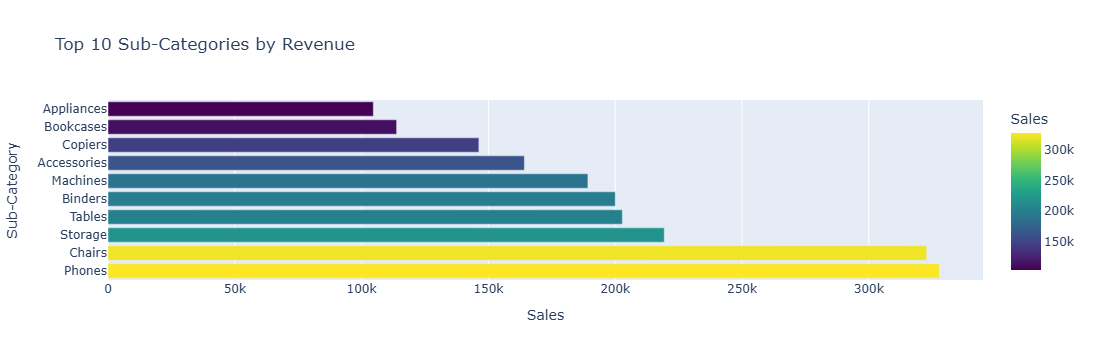

In [25]:
#top 10 category
sub_cat = df.groupby('Sub-Category')['Sales'].sum().reset_index()
sub_cat = sub_cat.sort_values('Sales', ascending=False).head(10)

fig5 = px.bar(sub_cat, x='Sales', y='Sub-Category',
              orientation='h',
              title='Top 10 Sub-Categories by Revenue',
              color='Sales',
              color_continuous_scale='Viridis')
fig5.show()

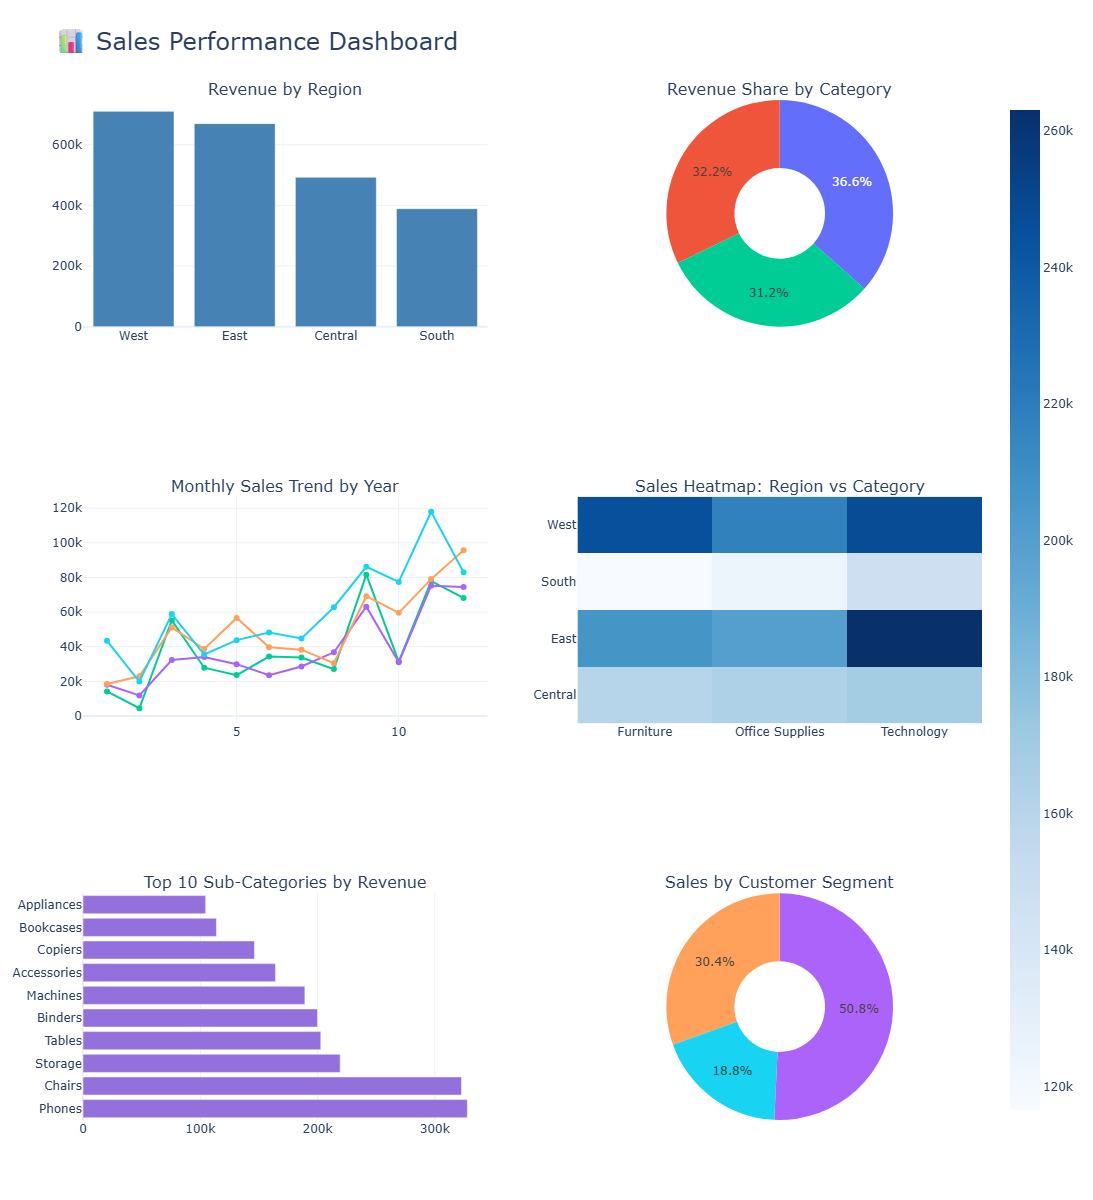

In [26]:
#Combined Dashboard (Single HTML File)
#dashboard
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        'Revenue by Region',
        'Revenue Share by Category',
        'Monthly Sales Trend by Year',
        'Sales Heatmap: Region vs Category',
        'Top 10 Sub-Categories by Revenue',
        'Sales by Customer Segment'
    ),
    specs=[
        [{"type": "bar"}, {"type": "pie"}],
        [{"type": "scatter"}, {"type": "heatmap"}],
        [{"type": "bar"}, {"type": "pie"}]
    ]
)

# Chart 1 - Revenue by Region
fig.add_trace(go.Bar(x=region_sales['Region'], y=region_sales['Total Sales'],
                     name='Region', marker_color='steelblue'), row=1, col=1)

# Chart 2 - Category Pie
fig.add_trace(go.Pie(labels=category_sales['Category'],
                     values=category_sales['Total Sales'],
                     name='Category', hole=0.4), row=1, col=2)

# Chart 3 - Monthly Trend
for year in monthly_sales['Year'].unique():
    temp = monthly_sales[monthly_sales['Year'] == year]
    fig.add_trace(go.Scatter(x=temp['Month'], y=temp['Sales'],
                             mode='lines+markers', name=str(year)), row=2, col=1)

# Chart 4 - Heatmap
fig.add_trace(go.Heatmap(z=pivot.values, x=pivot.columns.tolist(),
                          y=pivot.index.tolist(),
                          colorscale='Blues'), row=2, col=2)

# Chart 5 - Top Sub-Categories
fig.add_trace(go.Bar(x=sub_cat['Sales'], y=sub_cat['Sub-Category'],
                     orientation='h', name='Sub-Category',
                     marker_color='mediumpurple'), row=3, col=1)

# Chart 6 - Segment Pie
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()
fig.add_trace(go.Pie(labels=segment_sales['Segment'],
                     values=segment_sales['Sales'],
                     name='Segment', hole=0.4), row=3, col=2)

# Layout
fig.update_layout(
    height=1200,
    title_text=' Sales Performance Dashboard',
    title_font_size=24,
    showlegend=False,
    template='plotly_white'
)

fig.show()

In [27]:
# Export as HTML file (to share/portfolio):

fig.write_html("sales_dashboard.html")
print("Dashboard saved as sales_dashboard.html ")

Dashboard saved as sales_dashboard.html 


In [28]:
#Export Clean Data
df.to_csv("cleaned_sales_data.csv", index=False)
print("Cleaned data saved ")

Cleaned data saved 


In [30]:
#Save to Excel with multiple sheets:
with pd.ExcelWriter("sales_analysis.xlsx", engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Clean Data', index=False)
    region_sales.to_excel(writer, sheet_name='Region Sales', index=False)
    category_sales.to_excel(writer, sheet_name='Category Sales', index=False)
    monthly_sales.to_excel(writer, sheet_name='Monthly Sales', index=False)
    pivot.to_excel(writer, sheet_name='Pivot Table')

print("Excel file saved ")

Excel file saved 


In [ ]:
#